<a href="https://colab.research.google.com/github/MuhammadRabees/AI-ML-Internship-DevelopersHub/blob/main/Task_3_Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement
Heart disease is one of the leading causes of death worldwide.
The goal of this project is to build a machine learning model
that can predict whether a person is at risk of heart disease
based on medical attributes.

## Goal
- Clean and analyze medical dataset
- Perform Exploratory Data Analysis (EDA)
- Train a classification model
- Evaluate using Accuracy, Confusion Matrix, and ROC-AUC
- Identify important features affecting prediction

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

In [10]:
data = pd.read_csv("/content/heart_cleveland_upload.csv")
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


# Basic Data Cleaning

In [12]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# Exploratory Data Analysis (EDA)

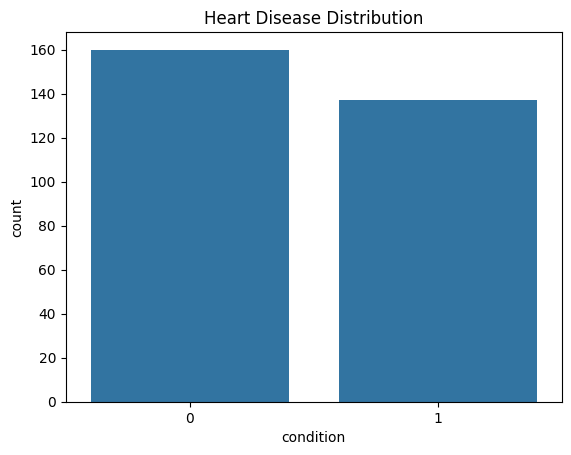

In [14]:
sns.countplot(x='condition', data=data)
plt.title("Heart Disease Distribution")
plt.show()

#Correlation Heatmap

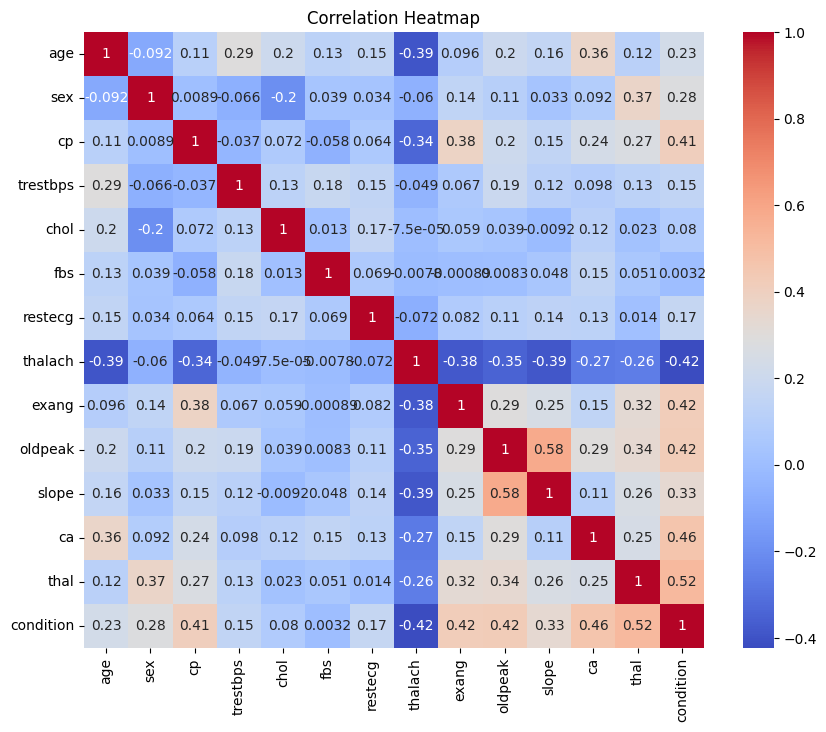

In [16]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Age vs Heart Disease

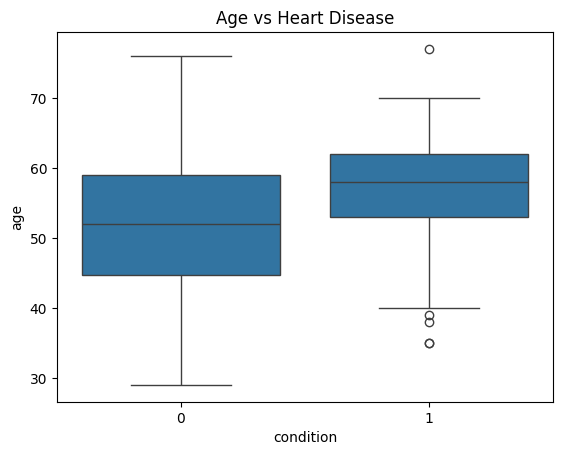

In [17]:
sns.boxplot(x='condition', y='age', data=data)
plt.title("Age vs Heart Disease")
plt.show()


# Defining Features and Targets

In [18]:
X = data.drop('condition', axis=1)
y = data['condition']

# Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model Training

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# Make Prediction

In [22]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7333333333333333


In [26]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,0,0
3,0,0
4,0,1
5,0,0
6,1,1
7,1,1
8,0,1
9,0,0


# Confusion Matrix

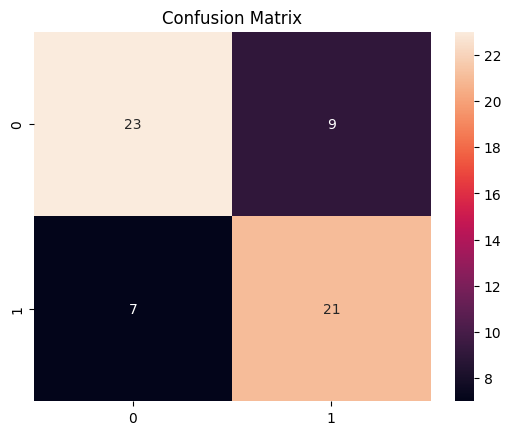

Confusion Matrix Interpretation:
True Negatives (TN): 23 → Model correctly predicted No Heart Disease.
False Positives (FP): 9 → Model predicted Disease, but person was healthy.
False Negatives (FN): 7 → Model predicted Healthy, but person had disease.
True Positives (TP): 21 → Model correctly predicted Heart Disease.


In [27]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix Interpretation:")
print("True Negatives (TN): 23 → Model correctly predicted No Heart Disease.")
print("False Positives (FP): 9 → Model predicted Disease, but person was healthy.")
print("False Negatives (FN): 7 → Model predicted Healthy, but person had disease.")
print("True Positives (TP): 21 → Model correctly predicted Heart Disease.")

# ROC Curve

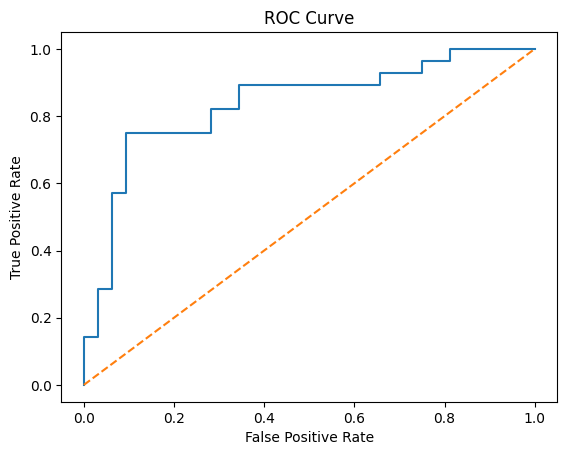

ROC-AUC Score: 0.8370535714285714
The ROC-AUC score of 0.837 indicates that the model has good ability
to distinguish between patients with and without heart disease.


In [30]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("The ROC-AUC score of 0.837 indicates that the model has good ability")
print("to distinguish between patients with and without heart disease.")

# Feature Importance

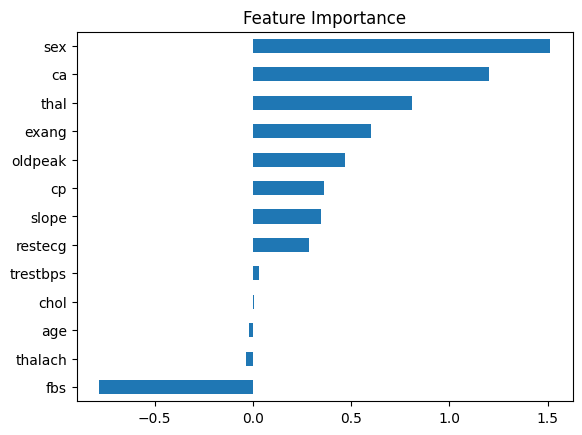

Important Features:
Sex, number of major vessels (ca), thalassemia (thal),
exercise-induced angina (exang), and ST depression (oldpeak)
are strong predictors of heart disease.


In [31]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

print("Important Features:")
print("Sex, number of major vessels (ca), thalassemia (thal),")
print("exercise-induced angina (exang), and ST depression (oldpeak)")
print("are strong predictors of heart disease.")